TRACKING REALSENSE T265 (AVOIDING)
---

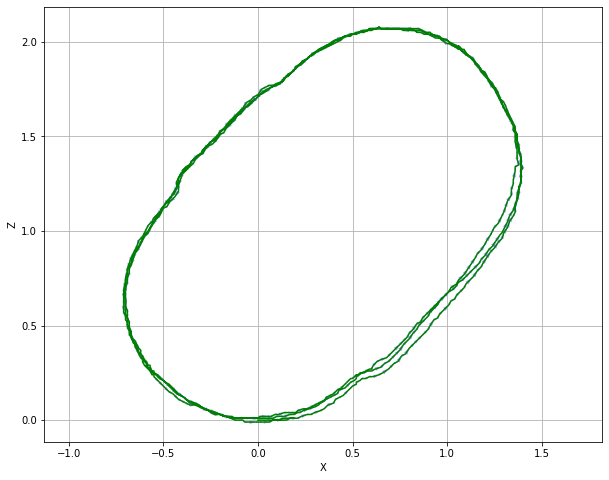

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("T265_tracking_data.csv", header=0, usecols=[0,1], sep=",")
df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors="coerce")
df.iloc[:, 1] = pd.to_numeric(df.iloc[:, 1], errors="coerce")
df = df.dropna()

z = df.iloc[:,0]
x = df.iloc[:,1]

plt.figure(figsize=(10, 8))
plt.plot(
    x, z, linestyle="-", color="green"
)

plt.quiver(
    x.iloc[:-1],
    z.iloc[:-1],
    x.diff().shift(-1).dropna(),
    z.diff().shift(-1).dropna(),
    scale_units="xy",
    angles="xy",
    scale=1,
    color="blue",
    alpha=0.4,
)

plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.axis("equal") 

plt.show()

TRACKING YOLO MODEL (AVOID)
---

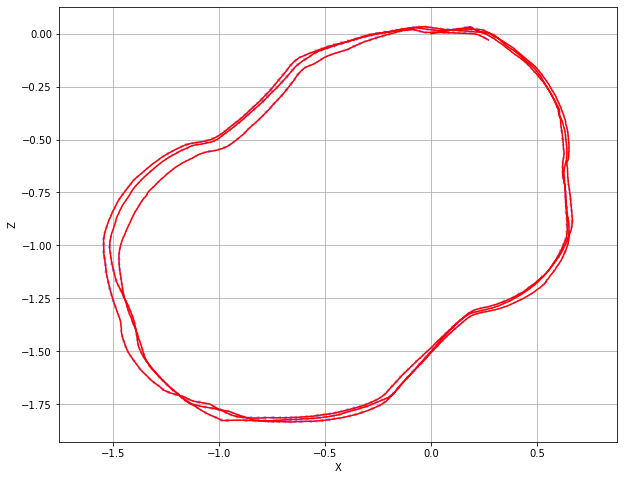

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("T265_tracking_data_YOLO.csv", header=0, usecols=[0,1], sep=",")
df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors="coerce")
df.iloc[:, 1] = pd.to_numeric(df.iloc[:, 1], errors="coerce")
df = df.dropna()

z = df.iloc[:,0]
x = df.iloc[:,1]

plt.figure(figsize=(10, 8))
plt.plot(
    x, z, linestyle="-", color="red"
)

plt.quiver(
    x.iloc[:-1],
    z.iloc[:-1],
    x.diff().shift(-1).dropna(),
    z.diff().shift(-1).dropna(),
    scale_units="xy",
    angles="xy",
    scale=1,
    color="blue",
    alpha=0.4,
)

plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.axis("equal") 

plt.show()

TRACKING T265 vs YOLO MODEL
---

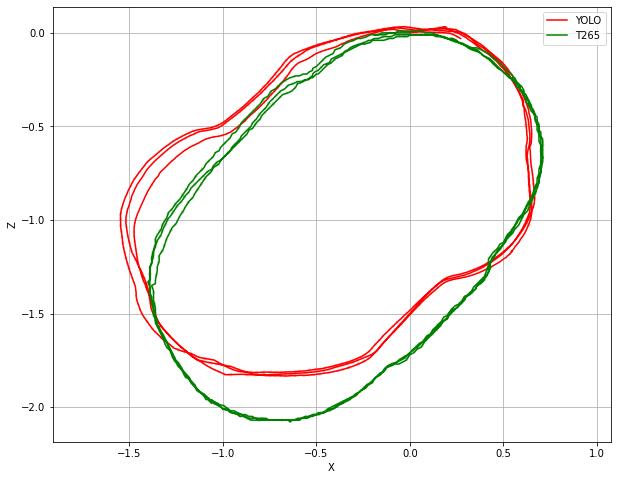

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def load_track(path):
    df = pd.read_csv(path, header=0, usecols=[0, 1], sep=",")
    df.iloc[:, 0] = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    df.iloc[:, 1] = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    df = df.dropna()
    z = df.iloc[:, 0].to_numpy()
    x = df.iloc[:, 1].to_numpy()
    return x, z

x1, z1 = load_track("T265_tracking_data_YOLO.csv")
x2, z2 = load_track("T265_tracking_data.csv")

x1c, z1c = x1 - x1[0], z1 - z1[0]
x2c, z2c = x2 - x2[0], z2 - z2[0]

x2_aligned = -x2c
z2_aligned = -z2c

plt.figure(figsize=(10, 8))

plt.plot(x1c, z1c, linestyle="-", color="red", label="YOLO")
plt.quiver(
    x1c[:-1], z1c[:-1],
    np.diff(x1c), np.diff(z1c),
    scale_units="xy", angles="xy", scale=1,
    color="red", alpha=0.3,
)

plt.plot(x2_aligned, z2_aligned, linestyle="-", color="green", label="T265")
plt.quiver(
    x2_aligned[:-1], z2_aligned[:-1],
    np.diff(x2_aligned), np.diff(z2_aligned),
    scale_units="xy", angles="xy", scale=1,
    color="green", alpha=0.3,
)

plt.xlabel("X")
plt.ylabel("Z")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()